In [11]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
emotions = load_dataset("emotion")
emotions.set_format(type="pandas")
df = emotions["train"][:]
df.head()

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\98922\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Fri Jan  2 23:41:12 2026).


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [8]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

In [9]:
df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


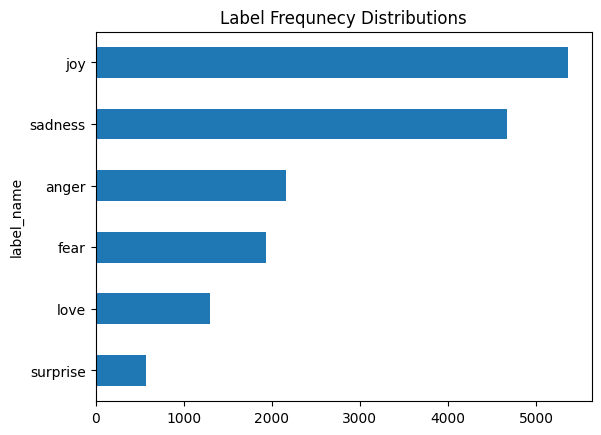

In [12]:
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Label Frequnecy Distributions")
plt.show()

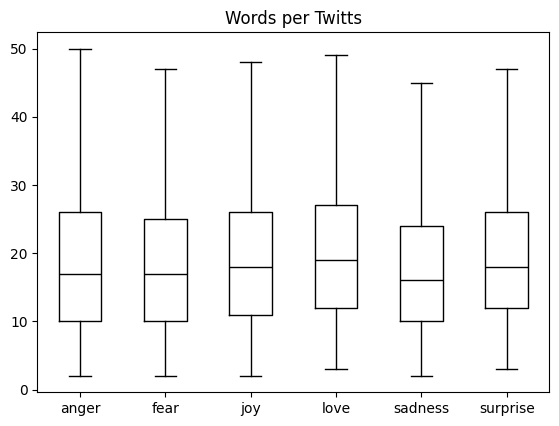

In [15]:
df["Words per Twitts"] = df["text"].str.split().apply(len)
df.boxplot("Words per Twitts", by='label_name',
           grid=False, showfliers=False, color='black')
plt.suptitle("")
plt.xlabel("")
plt.show()

In [16]:
emotions.reset_format()